# 02 — Rule-Based Ranker V1

Pure hand-crafted signals. No ML. No embeddings.

**Scoring formula:**
```
final_score = title_score × component_score × engagement_multiplier

component_score = skill_depth(0.35) + career_text(0.30) + career_history(0.15) + yoe(0.12) + location(0.08)
```

**Title is a multiplicative gate** — a Tier-0 HR Manager with `title_score = 0.05` physically cannot break into top 100 no matter how many AI keywords they stuffed.

**Every candidate row carries ALL raw fields** — dates, companies, skills+duration, honeypot flags — so you can sanity-check any rank manually.

In [1]:
import json, warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

# Data was generated with today's actual date as reference.
# Using 2025-01-01 causes Δ = -17 months on every current-job end_date=None,
# flagging 99,995 candidates as honeypots (false positives).
CURRENT_DATE = datetime(2026, 6, 8)

DATA_PATH    = Path('../candidates.jsonl')
OUT_DIR      = Path('../outputs'); OUT_DIR.mkdir(exist_ok=True)
OUT_CSV      = OUT_DIR / 'submission_v1_rulebased.csv'

print(f'CURRENT_DATE = {CURRENT_DATE.date()}')
print(f'Output → {OUT_CSV}')

CURRENT_DATE = 2026-06-08
Output → ..\outputs\submission_v1_rulebased.csv


In [2]:
# ── Title Tiers ───────────────────────────────────────────────────────────────
TIER5 = {
    'senior ai engineer','ml engineer','machine learning engineer','ai engineer',
    'applied ml engineer','nlp engineer','senior nlp engineer','search engineer',
    'recommendation systems engineer','ai research engineer',
    'staff machine learning engineer','lead ai engineer','ai specialist',
    'senior machine learning engineer','junior ml engineer'
}
TIER4 = {
    'data scientist','senior data scientist',
    'computer vision engineer','senior software engineer (ml)'
}
TIER3 = {
    'software engineer','senior software engineer',
    'backend engineer','full stack developer'
}
TIER2 = {
    'data engineer','analytics engineer','data analyst',
    'senior data engineer','cloud engineer','devops engineer'
}
TIER0 = {
    'hr manager','accountant','mechanical engineer','civil engineer',
    'content writer','marketing manager','sales executive','business analyst',
    'project manager','operations manager','customer support','graphic designer',
    'java developer','.net developer','mobile developer','frontend engineer','qa engineer'
}

TITLE_SCORE = {
    **{t: 1.00 for t in TIER5},
    **{t: 0.80 for t in TIER4},
    **{t: 0.40 for t in TIER3},
    **{t: 0.20 for t in TIER2},
    **{t: 0.05 for t in TIER0},
}

# ── Skill Tiers (calibrated from actual data — field is 'name', not 'skill_name') ──
# TIER_C: core retrieval/ranking infra that shows real depth
TIER_C = {
    'faiss','pinecone','weaviate','qdrant','milvus','pgvector',
    'opensearch','elasticsearch','bm25',
    'sentence transformers','hugging face transformers','llamaindex','haystack',
    'python','pytorch','tensorflow','scikit-learn',
    'lora','qlora','peft','weights & biases','wandb',
}
# TIER_B: applied AI/search patterns — relevant but easier to fake
TIER_B = {
    'langchain','embeddings','vector search','semantic search',
    'information retrieval','hybrid search',
    'recommendation systems','learning to rank',
    'rag','llms','fine-tuning','fine-tuning llms',
    'mlflow','mlops','bentoml','kubeflow','huggingface',
}
# TIER_A: cloud/infra — common, low differentiation
TIER_A = {'aws','gcp','azure','docker','kubernetes','terraform','airflow'}

ALL_JD  = TIER_C | TIER_B | TIER_A

# ── Career Text Keywords (retrieval/ranking domain signals) ───────────────────
CAREER_KW = [
    'vector','embedding','retrieval','semantic','rag','ranking','rerank',
    'faiss','bm25','fine-tun','llm','transformer','bert','inference',
    'recommendation','neural','language model','search','similarity',
    'index','ann','hnsw','dense retrieval','sparse','hybrid',
    'learning to rank','information retrieval','pgvector','llamaindex'
]

# ── Consulting firms ──────────────────────────────────────────────────────────
CONSULTING = {
    'tcs','infosys','wipro','accenture','cognizant','capgemini',
    'hcl','tech mahindra','mindtree','lti','hexaware','dxc'
}

AI_TITLE_KW = [
    'ml','ai','machine learning','data scientist','nlp',
    'neural','deep learning','computer vision','llm','language model'
]

print('Constants loaded.')
print(f'  Tier5={len(TIER5)}, Tier4={len(TIER4)}, Tier3={len(TIER3)}, Tier2={len(TIER2)}, Tier0={len(TIER0)}')
print(f'  SkillC={len(TIER_C)}, SkillB={len(TIER_B)}, SkillA={len(TIER_A)}')

Constants loaded.
  Tier5=15, Tier4=4, Tier3=4, Tier2=6, Tier0=17
  SkillC=22, SkillB=17, SkillA=7


In [3]:
print('Loading candidates...')
candidates = []
with open(DATA_PATH, encoding='utf-8') as f:
    for line in tqdm(f, desc='Reading'):
        line = line.strip()
        if line:
            candidates.append(json.loads(line))
print(f'Loaded {len(candidates):,} candidates')

# Verified honeypots from 03_honeypot_forensics.ipynb (source of truth).
import os
HP_PATH = OUT_DIR / 'honeypot_ids.csv'
if HP_PATH.exists():
    HONEYPOT_IDS = set(pd.read_csv(HP_PATH)['candidate_id'])
    print(f'Loaded {len(HONEYPOT_IDS)} verified honeypot ids from {HP_PATH.name}')
else:
    HONEYPOT_IDS = set()
    print('WARNING: honeypot_ids.csv not found — run 03 first. Falling back to inline check.')

Loading candidates...


Reading: 0it [00:00, ?it/s]

Loaded 100,000 candidates
Loaded 53 verified honeypot ids from honeypot_ids.csv


## Section 2 — Enhanced Honeypot Detection

Three independent checks. Each returns structured detail (not just a flag) so you can see *why* a candidate was flagged when inspecting the top-20.

| Check | What it looks for | Key fields exposed |
|---|---|---|
| `date_mismatch` | `start→end` actual months ≠ `duration_months` by >2 | `hp_date_detail` shows each bad job |
| `yoe_mismatch` | Sum of all `duration_months` > `years_of_experience × 12 + 18` | `hp_yoe_career`, `hp_yoe_delta` |
| `skill_anomaly` | ≥4 skills listed as expert/advanced with `duration_months = 0` | `hp_expert_zero_skills` lists them |

In [4]:
def check_honeypot(c):
    """
    Returns a dict with full forensic detail, not just a bool.
    NOTE: skill field is 'name' (not 'skill_name') in this dataset.
    """
    profile = c.get('profile', {})
    career  = c.get('career_history', []) or []
    skills  = c.get('skills', []) or []
    reasons = []

    # ── Check 1: start/end date vs claimed duration_months ───────────────────
    date_mismatches = []
    for i, job in enumerate(career):
        s_str   = job.get('start_date')
        e_str   = job.get('end_date')
        claimed = job.get('duration_months', 0) or 0
        try:
            s = datetime.strptime(s_str, '%Y-%m-%d') if s_str else None
            e = datetime.strptime(e_str, '%Y-%m-%d') if e_str else CURRENT_DATE
            if s and e:
                actual = (e.year - s.year) * 12 + (e.month - s.month)
                if abs(actual - claimed) > 2:
                    date_mismatches.append({
                        'idx':     i,
                        'company': job.get('company', '?'),
                        'title':   job.get('title',   '?'),
                        'start':   s_str,
                        'end':     e_str,
                        'claimed': claimed,
                        'actual':  actual,
                        'delta':   actual - claimed,
                    })
        except (ValueError, TypeError):
            pass
    if date_mismatches:
        reasons.append('date_mismatch')

    # ── Check 2: total career months vs claimed YoE ───────────────────────────
    yoe_claimed  = float(profile.get('years_of_experience', 0) or 0)
    total_months = sum(j.get('duration_months', 0) or 0 for j in career)
    yoe_career   = round(total_months / 12, 1)

    date_months = 0
    for job in career:
        try:
            s = datetime.strptime(job['start_date'], '%Y-%m-%d') if job.get('start_date') else None
            e = datetime.strptime(job['end_date'],   '%Y-%m-%d') if job.get('end_date')   else CURRENT_DATE
            if s and e:
                date_months += max(0, (e.year - s.year) * 12 + (e.month - s.month))
        except (ValueError, TypeError):
            pass
    yoe_dates = round(date_months / 12, 1)

    if total_months > yoe_claimed * 12 + 18:
        reasons.append('yoe_mismatch')

    # ── Check 3: expert/advanced skill with 0 months (field = 'name') ────────
    expert_zero = []
    for s in skills:
        prof = (s.get('proficiency') or '').lower()
        dur  = s.get('duration_months', 0) or 0
        if prof in ('expert', 'advanced') and dur == 0:
            expert_zero.append(s.get('name', '?'))   # ← correct field
    if len(expert_zero) >= 4:
        reasons.append('skill_anomaly')

    return {
        'is_honeypot':     bool(reasons),
        'reasons':         reasons,
        'date_mismatches': date_mismatches,
        'yoe_claimed':     yoe_claimed,
        'yoe_career':      yoe_career,
        'yoe_dates':       yoe_dates,
        'yoe_delta':       round(yoe_career - yoe_claimed, 1),
        'expert_zero':     expert_zero,
        'n_expert_zero':   len(expert_zero),
    }

print('check_honeypot() defined.')

check_honeypot() defined.


In [5]:
# Quick stats on honeypots across full dataset
hp_results = [check_honeypot(c) for c in tqdm(candidates, desc='Honeypot scan')]
n_hp = sum(1 for r in hp_results if r['is_honeypot'])

from collections import Counter
reason_counter = Counter()
for r in hp_results:
    for reason in r['reasons']:
        reason_counter[reason] += 1

print(f'Total honeypots detected: {n_hp} / {len(candidates):,}')
print(f'  date_mismatch:  {reason_counter["date_mismatch"]}')
print(f'  yoe_mismatch:   {reason_counter["yoe_mismatch"]}')
print(f'  skill_anomaly:  {reason_counter["skill_anomaly"]}')

Honeypot scan:   0%|          | 0/100000 [00:00<?, ?it/s]

Total honeypots detected: 53 / 100,000
  date_mismatch:  35
  yoe_mismatch:   24
  skill_anomaly:  13


## Section 3 — Scoring Functions

Each function is isolated and returns a `0.0–1.0` value.

| Function | Weight | What it measures |
|---|---|---|
| `title_score` | multiplicative gate | Title tier (1.00→0.05) |
| `skill_depth_score` | 0.35 | Tier-C/B/A skills × duration weight |
| `career_text_score` | 0.30 | Retrieval/ranking keywords in job descriptions |
| `career_hist_score` | 0.15 | Product company, AI trajectory, seniority |
| `yoe_score` | 0.12 | Peak 5–8 yrs, sweet spot 3–12 |
| `location_score` | 0.08 | India Tier-1 city → 1.0, global hub → 0.6 |
| `engagement_mult` | ×0.50–1.00 | Recency, response rate, notice, open-to-work |

In [6]:
def get_title_score(title):
    t = (title or '').lower().strip()
    return TITLE_SCORE.get(t, 0.15)


def get_skill_depth_score(skills):
    """Tier C/B/A weighted by duration + endorsements. Field is 'name'."""
    score = 0.0
    for s in skills:
        name = (s.get('name') or '').lower().strip()
        dur  = s.get('duration_months', 0) or 0
        end  = s.get('endorsements',   0) or 0
        dur_w  = min(1.0, dur / 24.0) if dur > 0 else 0.10
        end_w  = min(0.30, end / 30.0)
        weight = min(1.0, dur_w + end_w)
        if name in TIER_C:   score += 3.0 * weight
        elif name in TIER_B: score += 1.5 * weight
        elif name in TIER_A: score += 0.5 * weight
    return min(1.0, score / 10.0)


def get_career_text_score(career):
    if not career:
        return 0.0
    all_text = ' '.join((j.get('description') or '') + ' ' + (j.get('title') or '')
                        for j in career).lower()
    hits = sum(1 for kw in CAREER_KW if kw in all_text)
    return min(1.0, hits / 5.0)


def get_career_hist_score(career):
    if not career:
        return 0.0
    score     = 0.0
    companies = [(j.get('company') or '').lower() for j in career]
    titles    = [(j.get('title')   or '').lower() for j in career]
    if not any(any(ck in co for ck in CONSULTING) for co in companies):
        score += 0.30
    ai_count = sum(1 for t in titles if any(kw in t for kw in AI_TITLE_KW))
    score += min(0.35, ai_count * 0.12)
    if titles and any(kw in titles[-1] for kw in AI_TITLE_KW):
        score += 0.10
    if any(any(kw in t for kw in ['senior','lead','staff','principal','head','director']) for t in titles):
        score += 0.10
    n_real_jobs = sum(1 for j in career if (j.get('duration_months') or 0) > 0)
    score += min(0.15, n_real_jobs * 0.05)
    return min(1.0, score)


def get_yoe_score(yoe):
    if yoe is None: return 0.0
    yoe = float(yoe)
    if 5 <= yoe <= 8:    return 1.00
    elif 3 <= yoe < 5:   return 0.70 + (yoe - 3)  * 0.15
    elif 8 < yoe <= 12:  return 1.00 - (yoe - 8)  * 0.05
    elif 12 < yoe <= 18: return 0.80 - (yoe - 12) * 0.04
    elif 1 <= yoe < 3:   return 0.20 + yoe * 0.15
    else:                return 0.10


def get_location_score(country, location):
    country  = (country  or '').lower().strip()
    location = (location or '').lower().strip()
    if country == 'india':
        tier1 = ['bangalore','bengaluru','mumbai','hyderabad','pune',
                 'delhi','gurgaon','gurugram','noida','chennai']
        return 1.0 if any(c in location for c in tier1) else 0.8
    elif country in ['usa','united states','us','uk','united kingdom',
                     'canada','germany','singapore','netherlands','australia']:
        return 0.6
    else:
        return 0.4


def _parse_date(d):
    try:    return datetime.strptime(d, '%Y-%m-%d') if d else None
    except (ValueError, TypeError): return None


def get_engagement_mult(rs):
    """Range 0.50-1.00 from REAL redrob_signals fields (not 'engagement')."""
    if not rs:
        return 0.70
    score = 0.0
    la = _parse_date(rs.get('last_active_date'))
    if la:
        days = (CURRENT_DATE - la).days
        if   days <= 7:   score += 0.30
        elif days <= 30:  score += 0.22
        elif days <= 90:  score += 0.14
        elif days <= 180: score += 0.07
        else:             score += 0.02
    else:
        score += 0.07
    rr = float(rs.get('recruiter_response_rate', 0.5) or 0.5)
    score += rr * 0.25
    notice = float(rs.get('notice_period_days', 60) or 60)
    if   notice <= 15: score += 0.25
    elif notice <= 30: score += 0.20
    elif notice <= 60: score += 0.12
    else:              score += 0.04
    if rs.get('open_to_work_flag', False):
        score += 0.20
    return 0.50 + min(0.50, score * 0.50)


def get_assessment_score(rs, skills):
    """
    Positive quality signal: mean skill_assessment_score over AI-relevant skills,
    normalised 0-1. Separates a REAL expert (PyTorch=85) from a claimed one (40).
    Returns (norm_score, mean_raw, n_assessments). 0 when no assessments (~76% of pool).
    """
    if not rs:
        return 0.0, None, 0
    sas = rs.get('skill_assessment_scores', {}) or {}
    if not sas:
        return 0.0, None, 0
    # prefer AI-relevant skill assessments; fall back to all
    ai_scores = [sc for sk, sc in sas.items()
                 if (sk or '').lower() in ALL_JD and isinstance(sc, (int, float))]
    use = ai_scores if ai_scores else [sc for sc in sas.values() if isinstance(sc, (int, float))]
    if not use:
        return 0.0, None, 0
    mean_raw = sum(use) / len(use)
    return min(1.0, mean_raw / 100.0), round(mean_raw, 1), len(use)


print('Scoring functions defined (real engagement + assessment signal).')

Scoring functions defined (real engagement + assessment signal).


## Section 4 — Score Every Candidate

`score_candidate()` returns a **flat dict with 45+ fields** — every raw signal, every partial score, every honeypot flag.
This means the resulting DataFrame is your inspection tool: sort by any column, filter on any flag, no black boxes.

In [7]:
def score_candidate(c):
    cid     = c.get('candidate_id', '')
    profile = c.get('profile', {})
    career  = c.get('career_history', []) or []
    skills  = c.get('skills', []) or []
    rs      = c.get('redrob_signals') or {}      # <-- correct key (was 'engagement')

    title    = profile.get('current_title', '') or ''
    yoe      = profile.get('years_of_experience', 0) or 0
    country  = profile.get('country',  '') or ''
    location = profile.get('location', '') or ''
    name     = profile.get('anonymized_name', '') or ''

    hp = check_honeypot(c)
    # exclusion = verified list (source of truth) OR inline detection as backup
    is_excluded = (cid in HONEYPOT_IDS) or hp['is_honeypot']

    title_lower = title.lower().strip()
    is_tier0    = title_lower in TIER0
    skill_names = {(s.get('name') or '').lower().strip() for s in skills}
    n_jd_skills = len(skill_names & ALL_JD)
    is_stuffer  = is_tier0 and n_jd_skills >= 4

    tier_c_present = sorted(skill_names & TIER_C)
    tier_b_present = sorted(skill_names & TIER_B)
    tier_a_present = sorted(skill_names & TIER_A)

    companies     = [j.get('company', '') or '' for j in career]
    career_titles = [j.get('title',   '') or '' for j in career]

    earliest_start = None
    for job in career:
        d = _parse_date(job.get('start_date'))
        if d and (earliest_start is None or d < earliest_start):
            earliest_start = d
    career_span_yrs = round((CURRENT_DATE - earliest_start).days / 365, 1) if earliest_start else None

    is_consulting   = any(any(ck in co.lower() for ck in CONSULTING) for co in companies if co)
    has_senior_flag = any(any(kw in t.lower() for kw in ['senior','lead','staff','principal','head','director'])
                          for t in career_titles)

    all_text = ' '.join((j.get('description') or '') + ' ' + (j.get('title') or '')
                        for j in career).lower()
    career_kw_hits = [kw for kw in CAREER_KW if kw in all_text]

    t_score  = get_title_score(title)
    s_score  = get_skill_depth_score(skills)
    ct_score = get_career_text_score(career)
    ch_score = get_career_hist_score(career)
    y_score  = get_yoe_score(yoe)
    l_score  = get_location_score(country, location)
    e_mult   = get_engagement_mult(rs)
    a_score, mean_assess, n_assess = get_assessment_score(rs, skills)

    # rebalanced component weights (sum = 1.00) — assessment breaks ties
    component = (
        s_score  * 0.30 +
        ct_score * 0.25 +
        ch_score * 0.13 +
        y_score  * 0.10 +
        l_score  * 0.07 +
        a_score  * 0.15
    )

    final = 0.0 if is_excluded else t_score * component * e_mult

    return {
        'candidate_id': cid, 'name': name, 'title': title,
        'country': country, 'location': location, 'yoe_claimed': yoe,
        'is_honeypot': is_excluded, 'hp_reasons': '|'.join(hp['reasons']),
        'hp_yoe_delta': hp['yoe_delta'], 'hp_n_expert_zero': hp['n_expert_zero'],
        'hp_expert_zero': '|'.join(hp['expert_zero'][:6]),
        'is_stuffer': is_stuffer, 'is_tier0': is_tier0, 'n_jd_skills': n_jd_skills,
        'n_skills': len(skills), 'n_tier_c': len(tier_c_present),
        'n_tier_b': len(tier_b_present), 'n_tier_a': len(tier_a_present),
        'tier_c_list': '|'.join(tier_c_present), 'tier_b_list': '|'.join(tier_b_present),
        'n_jobs': len(career), 'companies': ' -> '.join(companies[:5]),
        'career_titles': ' -> '.join(career_titles[:5]),
        'career_span_yrs': career_span_yrs, 'is_consulting': is_consulting,
        'has_senior_title': has_senior_flag, 'n_career_kw': len(career_kw_hits),
        'career_kw_list': '|'.join(career_kw_hits[:10]),
        'n_assessments': n_assess, 'mean_assessment': mean_assess,
        'last_active_date':  rs.get('last_active_date'),
        'response_rate':     rs.get('recruiter_response_rate'),
        'notice_period_days': rs.get('notice_period_days'),
        'open_to_work':      rs.get('open_to_work_flag'),
        'github_score':      rs.get('github_activity_score'),
        'score_title': round(t_score,4), 'score_skill': round(s_score,4),
        'score_cartext': round(ct_score,4), 'score_carhist': round(ch_score,4),
        'score_yoe': round(y_score,4), 'score_loc': round(l_score,4),
        'score_assess': round(a_score,4), 'score_eng': round(e_mult,4),
        'score_final': round(final,6),
    }

print('score_candidate() defined (redrob_signals + assessment + verified honeypots).')

score_candidate() defined (redrob_signals + assessment + verified honeypots).


In [8]:
print('Scoring all candidates...')
rows = [score_candidate(c) for c in tqdm(candidates, desc='Scoring')]
df = pd.DataFrame(rows)
df.sort_values('score_final', ascending=False, inplace=True)
df.reset_index(drop=True, inplace=True)
df.index += 1   # rank starts at 1

print(f'DataFrame shape: {df.shape}')
print(f'\nHoneypots excluded:  {df["is_honeypot"].sum():,}')
print(f'Keyword stuffers:    {df["is_stuffer"].sum():,}')
print(f'Non-zero scores:     {(df["score_final"] > 0).sum():,}')
print(f'\nTop score: {df["score_final"].iloc[0]:.4f}')
print(f'Score at rank 100: {df["score_final"].iloc[99]:.4f}')

Scoring all candidates...


Scoring:   0%|          | 0/100000 [00:00<?, ?it/s]

DataFrame shape: (100000, 44)

Honeypots excluded:  53
Keyword stuffers:    8,101
Non-zero scores:     99,947

Top score: 0.8822
Score at rank 100: 0.7193


## Section 5 — Inspect Results

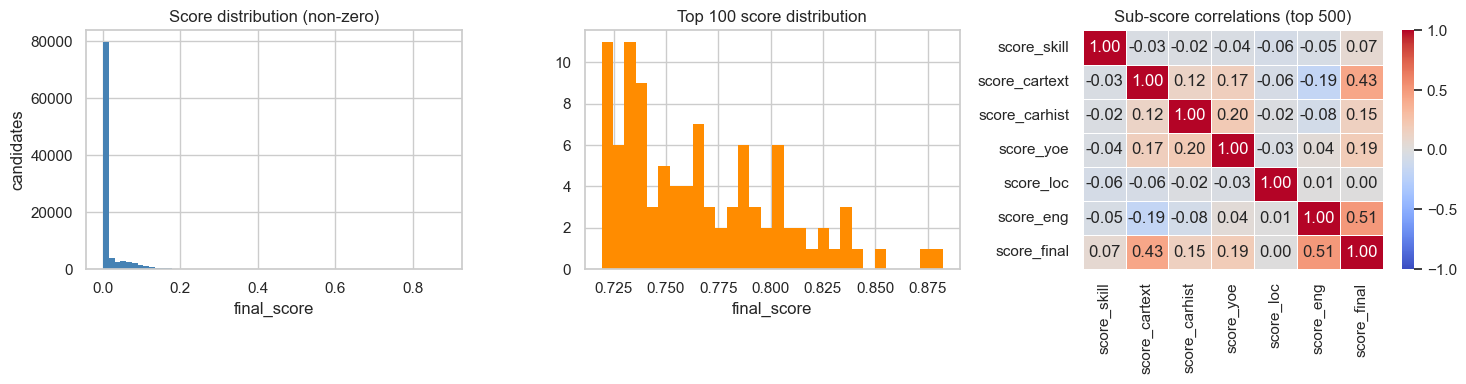

Score distribution chart saved.


In [9]:
# ── Score distribution across all candidates ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

nonzero = df[df['score_final'] > 0]['score_final']
top100  = df.head(100)['score_final']

axes[0].hist(nonzero, bins=60, color='steelblue', edgecolor='none')
axes[0].set_title('Score distribution (non-zero)')
axes[0].set_xlabel('final_score')
axes[0].set_ylabel('candidates')

axes[1].hist(top100, bins=30, color='darkorange', edgecolor='none')
axes[1].set_title('Top 100 score distribution')
axes[1].set_xlabel('final_score')

# Sub-score correlation heatmap (top 500)
score_cols = ['score_skill','score_cartext','score_carhist','score_yoe','score_loc','score_eng','score_final']
corr = df.head(500)[score_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2], vmin=-1, vmax=1, linewidths=0.5)
axes[2].set_title('Sub-score correlations (top 500)')

plt.tight_layout()
plt.savefig(OUT_DIR / 'v1_score_distribution.png', dpi=120)
plt.show()
print('Score distribution chart saved.')

In [10]:
# -- Top 20 -- FULL DETAIL VIEW --
INSPECT_COLS = [
    'candidate_id','name','title','country','location','yoe_claimed',
    'is_honeypot','hp_reasons','hp_yoe_delta','hp_n_expert_zero','hp_expert_zero',
    'is_stuffer','is_tier0','n_jd_skills',
    'n_tier_c','n_tier_b','n_tier_a','tier_c_list','tier_b_list',
    'n_jobs','companies','career_titles','career_span_yrs','is_consulting',
    'has_senior_title','n_career_kw','career_kw_list',
    'n_assessments','mean_assessment',
    'last_active_date','response_rate','notice_period_days','open_to_work','github_score',
    'score_title','score_skill','score_cartext','score_carhist',
    'score_yoe','score_loc','score_assess','score_eng','score_final',
]
top20 = df.head(20)[INSPECT_COLS].copy()
print("=== TOP 20 -- FULL DETAIL ===")
display(top20)

=== TOP 20 -- FULL DETAIL ===


,candidate_id,name,title,country,location,yoe_claimed,is_honeypot,hp_reasons,hp_yoe_delta,hp_n_expert_zero,hp_expert_zero,is_stuffer,is_tier0,n_jd_skills,n_tier_c,n_tier_b,n_tier_a,tier_c_list,tier_b_list,n_jobs,companies,career_titles,career_span_yrs,is_consulting,has_senior_title,n_career_kw,career_kw_list,n_assessments,mean_assessment,last_active_date,response_rate,notice_period_days,open_to_work,github_score,score_title,score_skill,score_cartext,score_carhist,score_yoe,score_loc,score_assess,score_eng,score_final
1,CAND_0011687,Shreya Tiwari,Senior NLP Engineer,India,"Indore, Madhya Pradesh",7.8000,False,,-0.1000,0,,False,False,11,7,4,0,faiss|llamaindex|opensearch|peft|pytorch|tensorflow|weaviate,embeddings|langchain|mlops|semantic search,2,Niramai -> Krutrim,Senior NLP Engineer -> Senior Machine Learning Engineer,7.6000,False,True,6,embedding|retrieval|ranking|fine-tun|inference|recommendation,1,78.1000,2026-05-10,0.8900,15,True,76.3000,1.0000,1.0000,1.0000,0.8400,1.0000,0.8000,0.7810,0.9463,0.8822
2,CAND_0018499,Aarav Trivedi,Senior Machine Learning Engineer,India,"Noida, Uttar Pradesh",7.2000,False,,0.0000,0,,False,False,13,7,6,0,bm25|milvus|pinecone|qlora|scikit-learn|weaviate|weights & biases,embeddings|information retrieval|langchain|learning to rank|rag|recommendation systems,3,Zomato -> Google -> Flipkart,Senior Machine Learning Engineer -> Staff Machine Learning Engineer -> Senior Machine ...,7.1000,False,True,13,embedding|retrieval|rag|ranking|rerank|faiss|bm25|fine-tun|llm|inference,1,72.4000,2026-05-13,0.6100,15,True,94.8000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.7240,0.9113,0.8735
3,CAND_0033445,Ved Bhatia,ML Engineer,India,"Ahmedabad, Gujarat",6.8000,False,,-0.1000,0,,False,False,9,4,4,1,bm25|hugging face transformers|pgvector|weights & biases,information retrieval|mlops|recommendation systems|semantic search,3,Vedantu -> Niramai -> upGrad,ML Engineer -> AI Specialist -> ML Engineer,6.7000,False,False,5,fine-tun|llm|transformer|bert|inference,2,64.8000,2026-05-26,0.9400,30,True,-1.0000,1.0000,1.0000,1.0000,0.9000,1.0000,0.8000,0.6485,0.9275,0.8536
4,CAND_0046525,Tanvi Mukherjee,Senior Machine Learning Engineer,India,"Pune, Maharashtra",6.1000,False,,0.0000,0,,False,False,10,7,3,0,elasticsearch|llamaindex|pgvector|qdrant|sentence transformers|tensorflow|weights & bi...,information retrieval|langchain|llms,2,Genpact AI -> LinkedIn,Senior Machine Learning Engineer -> Senior Machine Learning Engineer,6.2000,False,True,12,embedding|retrieval|rag|ranking|rerank|faiss|bm25|llm|search|index,4,84.0000,2026-05-23,0.8800,60,True,36.7000,1.0000,1.0000,1.0000,0.8400,1.0000,1.0000,0.8403,0.8800,0.8406
5,CAND_0040887,Meera Kumar,Machine Learning Engineer,Canada,Toronto,4.7000,False,,-0.1000,0,,False,False,8,5,3,0,faiss|lora|milvus|peft|python,langchain|mlflow|recommendation systems,2,Netflix -> Unacademy,Machine Learning Engineer -> AI Engineer,4.6000,False,False,9,embedding|retrieval|semantic|rag|faiss|bm25|fine-tun|transformer|search,1,70.8000,2026-05-24,0.8400,15,True,34.2000,1.0000,1.0000,1.0000,0.7400,0.9550,0.6000,0.7080,0.9400,0.8365
6,CAND_0064326,Nisha Pillai,Search Engineer,India,"Gurgaon, Haryana",7.6000,False,,0.0000,0,,False,False,10,8,2,0,bm25|milvus|python|pytorch|qlora|scikit-learn|weaviate|weights & biases,rag|semantic search,4,Sarvam AI -> Aganitha -> Freshworks -> Apple,Search Engineer -> Machine Learning Engineer -> Machine Learning Engineer -> Machine L...,7.8000,False,False,5,embedding|rag|ranking|fine-tun|search,3,69.3000,2026-05-21,0.9400,45,True,61.4000,1.0000,1.0000,1.0000,0.9000,1.0000,1.0000,0.6930,0.8875,0.8351
7,CAND_0043860,Pranav Sharma,Junior ML Engineer,India,"Bhubaneswar, Odisha",6.1000,False,,0.0000,0,,False,False,6,3,3,0,pgvector|pytorch|qdrant,information retrieval|semantic search|vector search,2,Aganitha -> Nykaa,Junior ML Engineer -> Senior Software Engineer (ML),6.0000,False,True,5,ranking|fine-tun|llm|inference|recommendation,2,66.9000,2026-05-26,0.8100,30,True,-1.0000,1.0000,1

In [11]:
# -- Where do honeypots land in the ranking? --
cols = ["candidate_id","name","title","hp_reasons","hp_yoe_delta",
        "hp_n_expert_zero","hp_expert_zero","score_final"]
hp_df = df[df["is_honeypot"]].head(20)[cols]
in_top100 = df.head(100)["is_honeypot"].sum()
total_hp  = df["is_honeypot"].sum()
print("Honeypots in top 100:", in_top100, " (must be 0)")
print("Total excluded honeypots:", total_hp)
print()
display(hp_df)


Honeypots in top 100: 0  (must be 0)
Total excluded honeypots: 53



,candidate_id,name,title,hp_reasons,hp_yoe_delta,hp_n_expert_zero,hp_expert_zero,score_final
99948,CAND_0093364,Amit Agarwal,Business Analyst,date_mismatch|yoe_mismatch,9.6000,0,,0.0000
99949,CAND_0003430,Atharv Ghosh,Business Analyst,date_mismatch,-12.8000,0,,0.0000
99950,CAND_0038431,Tanvi Iyer,Mobile Developer,date_mismatch,-13.7000,0,,0.0000
99951,CAND_0093547,Arnav Ghosh,Senior Machine Learning Engineer,yoe_mismatch,3.3000,0,,0.0000
99952,CAND_0001610,Aryan Banerjee,Machine Learning Engineer,yoe_mismatch,2.1000,0,,0.0000
99953,CAND_0043721,Ela Patel,Sales Executive,date_mismatch|yoe_mismatch,4.5000,0,,0.0000
99954,CAND_0056983,Arnav Mittal,Accountant,skill_anomaly,-0.3000,5,Rust|Next.js|Redis|Salesforce CRM|MongoDB,0.0000
99955,CAND_0096150,Vikram Pandey,Accountant,date_mismatch,-13.9000,0,,0.0000
99956,CAND_0072379,Aditya Menon,Content Writer,skill_anomaly,-0.1000,4,Azure|Redux|Illustrator|Spark,0.0000
99957,CAND_0091068,Nikhil Agarwal,HR Manager,date_mismatch,-11.7000,0,,0.0000


In [12]:
# ── Where do keyword stuffers land? ──────────────────────────────────────────
# Should NOT appear in top 100. The title gate (0.05) keeps them out.
stuffers_in_top100 = df.head(100)[df.head(100)['is_stuffer']]
print(f'Keyword stuffers in top 100: {len(stuffers_in_top100)}  ← must be 0')

# Show where the top-ranked stuffer ended up
top_stuffer_rank = df[df['is_stuffer']].index.min()
print(f'Best-ranked stuffer is at rank: {top_stuffer_rank}')

# Sample stuffers and their scores
sample_stuffers = df[df['is_stuffer']].head(5)[
    ['candidate_id','name','title','n_jd_skills','tier_c_list',
     'score_title','score_skill','score_final']
]
print('\nSample stuffers (title_score=0.05 kills them):')
display(sample_stuffers)

Keyword stuffers in top 100: 0  ← must be 0
Best-ranked stuffer is at rank: 16612

Sample stuffers (title_score=0.05 kills them):


,candidate_id,name,title,n_jd_skills,tier_c_list,score_title,score_skill,score_final
16612,CAND_0049336,Kavya Chatterjee,Sales Executive,9,hugging face transformers|pinecone|sentence transformers|weights & biases,0.0500,1.0000,0.0275
16656,CAND_0012397,Ayaan Mukherjee,Business Analyst,8,faiss|hugging face transformers|sentence transformers|weights & biases,0.0500,1.0000,0.0270
16713,CAND_0039982,Aryan Sen,HR Manager,10,faiss|hugging face transformers|pinecone,0.0500,1.0000,0.0265
16755,CAND_0067453,Rahul Saxena,Content Writer,11,faiss|hugging face transformers|sentence transformers,0.0500,0.9500,0.0261
16760,CAND_0098215,Aryan Gupta,Marketing Manager,11,faiss|pinecone|sentence transformers|weights & biases,0.0500,1.0000,0.0260


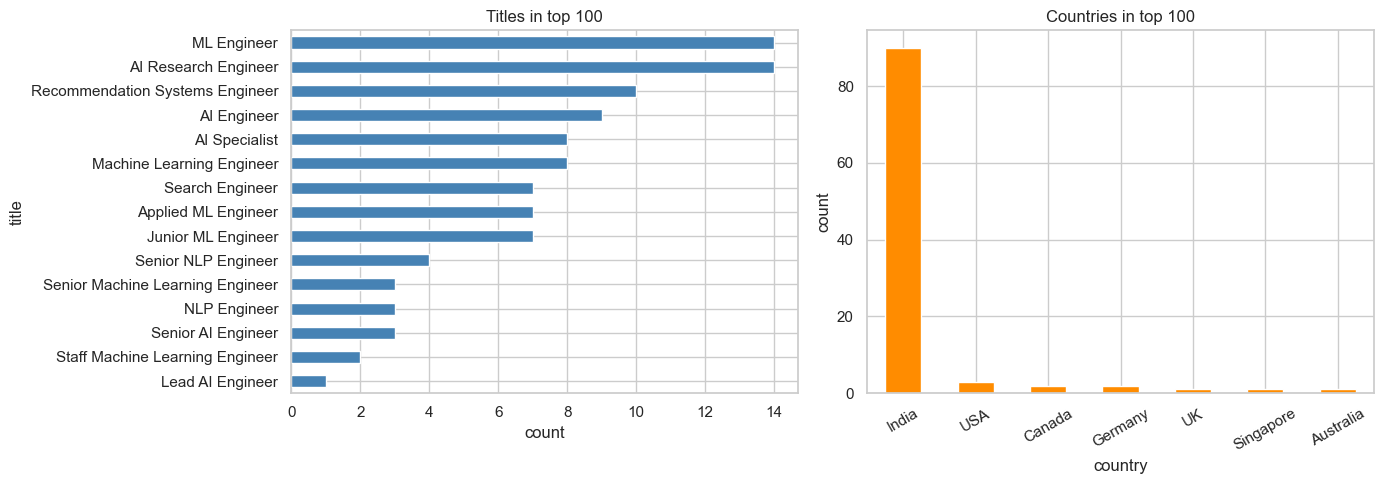

In [13]:
# ── Title distribution in top 100 ────────────────────────────────────────────
title_counts = df.head(100)['title'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

title_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Titles in top 100')
axes[0].set_xlabel('count')
axes[0].invert_yaxis()

# Country distribution in top 100
country_counts = df.head(100)['country'].value_counts().head(10)
country_counts.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Countries in top 100')
axes[1].set_ylabel('count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUT_DIR / 'v1_top100_breakdown.png', dpi=120)
plt.show()

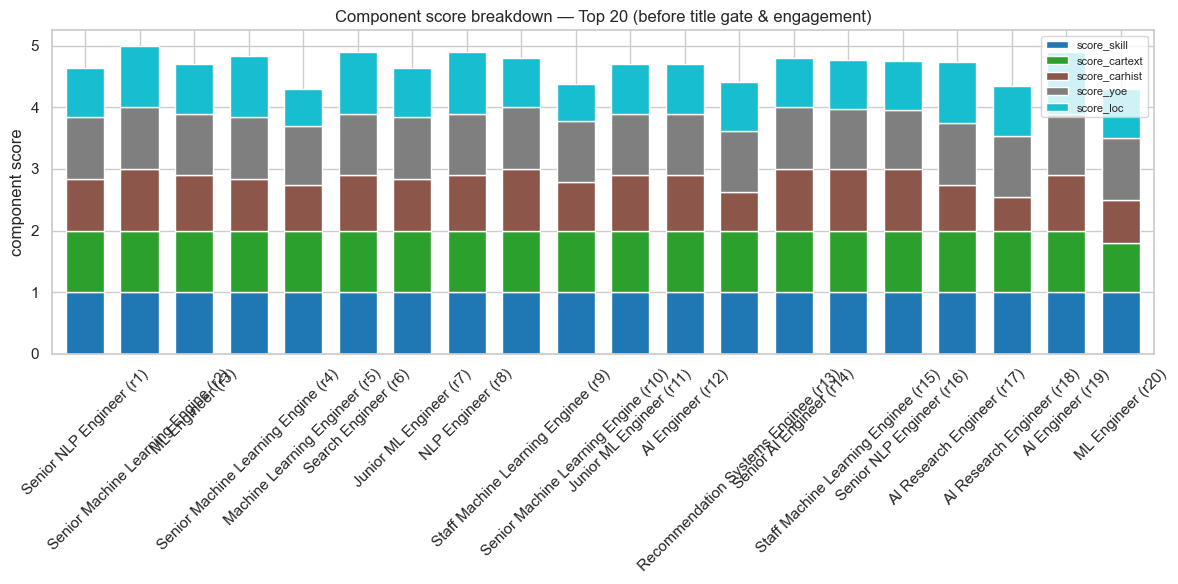

In [14]:
# ── Score breakdown: what's driving the top 20? ───────────────────────────────
breakdown_cols = ['score_title','score_skill','score_cartext','score_carhist',
                  'score_yoe','score_loc','score_eng','score_final']

fig, ax = plt.subplots(figsize=(12, 6))
plot_data = df.head(20)[breakdown_cols].copy()
plot_data.index = df.head(20)['title'].str[:30] + ' (r' + df.head(20).index.astype(str) + ')'
plot_data[['score_skill','score_cartext','score_carhist','score_yoe','score_loc']].plot(
    kind='bar', stacked=True, ax=ax, colormap='tab10', width=0.7)
ax.set_title('Component score breakdown — Top 20 (before title gate & engagement)')
ax.set_ylabel('component score')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'v1_component_breakdown.png', dpi=120)
plt.show()

## Section 6 — Save CSV & Validate

Submission format: `candidate_id` column, rows ranked 1–100.

In [15]:
# ── Build submission in the OFFICIAL 4-column format ──────────────────────────
# Required header (exact order): candidate_id, rank, score, reasoning
# Rules enforced by validate_submission.py:
#   - exactly 100 data rows
#   - candidate_id matches CAND_[0-9]{7}
#   - rank = integer 1..100, each exactly once
#   - score = float, NON-INCREASING by rank
#   - ties (equal score): candidate_id must be ASCENDING
#
# Round score to 4 decimals (like the sample) BEFORE sorting so the on-disk
# ordering is fully consistent with the values written.

work = df.copy()
work['score'] = work['score_final'].round(4)
work.sort_values(['score', 'candidate_id'], ascending=[False, True], inplace=True)
work.reset_index(drop=True, inplace=True)

top = work.head(100).copy()
top['rank'] = range(1, 101)


def make_reasoning(r):
    """Human-readable justification from real signals (no fabrication)."""
    bits = [f"{r['title']} with {r['yoe_claimed']:.1f} yrs"]
    bits.append(f"{r['n_tier_c']} core + {r['n_tier_b']} applied AI skills")
    if r['n_career_kw'] > 0:
        bits.append(f"{r['n_career_kw']} retrieval/ranking JD signals")
    if not r['is_consulting']:
        bits.append("product company background")
    if r['has_senior_title']:
        bits.append("senior trajectory")
    rr = r['response_rate']
    if rr is not None and rr == rr:  # not NaN
        bits.append(f"response rate {float(rr):.2f}")
    return ('; '.join(bits) + '.').replace('\n', ' ').strip()


top['reasoning'] = top.apply(make_reasoning, axis=1)
submission = top[['candidate_id', 'rank', 'score', 'reasoning']].copy()
submission.to_csv(OUT_CSV, index=False, encoding='utf-8', float_format='%.4f')

print(f'Saved: {OUT_CSV}')
print(f'Rows: {len(submission)}  Columns: {list(submission.columns)}')
print()
print(submission.head(10).to_string(index=False))

Saved: ..\outputs\submission_v1_rulebased.csv
Rows: 100  Columns: ['candidate_id', 'rank', 'score', 'reasoning']

candidate_id  rank  score                                                                                                                                                                        reasoning
CAND_0011687     1 0.8822               Senior NLP Engineer with 7.8 yrs; 7 core + 4 applied AI skills; 6 retrieval/ranking JD signals; product company background; senior trajectory; response rate 0.89.
CAND_0018499     2 0.8735 Senior Machine Learning Engineer with 7.2 yrs; 7 core + 6 applied AI skills; 13 retrieval/ranking JD signals; product company background; senior trajectory; response rate 0.61.
CAND_0033445     3 0.8536                                          ML Engineer with 6.8 yrs; 4 core + 4 applied AI skills; 5 retrieval/ranking JD signals; product company background; response rate 0.94.
CAND_0046525     4 0.8406 Senior Machine Learning Engineer with 6.1 yrs; 7

In [16]:
# ── Validate against the official rules (mirrors validate_submission.py) ──────
import csv, re

REQUIRED_HEADER = ["candidate_id", "rank", "score", "reasoning"]
CID_PAT = re.compile(r"^CAND_[0-9]{7}$")
errors = []

with open(OUT_CSV, "r", encoding="utf-8", newline="") as f:
    rows = list(csv.reader(f))

header, data = rows[0], [r for r in rows[1:] if any(c.strip() for c in r)]

if header != REQUIRED_HEADER:
    errors.append(f"Header mismatch: {header}")
if len(data) != 100:
    errors.append(f"Expected 100 data rows, found {len(data)}")

seen_ids, seen_ranks, by_rank = set(), set(), []
for i, cells in enumerate(data):
    rn = i + 2
    if len(cells) != 4:
        errors.append(f"Row {rn}: expected 4 cols, got {len(cells)}"); continue
    cid, rank_s, score_s, _ = cells
    cid = cid.strip()
    if not CID_PAT.match(cid):    errors.append(f"Row {rn}: bad candidate_id {cid!r}")
    elif cid in seen_ids:         errors.append(f"Row {rn}: duplicate id {cid}")
    else:                         seen_ids.add(cid)
    try:
        rank = int(rank_s)
        if str(rank) != rank_s.strip() or not 1 <= rank <= 100:
            errors.append(f"Row {rn}: bad rank {rank_s!r}")
        elif rank in seen_ranks:  errors.append(f"Row {rn}: duplicate rank {rank}")
        else:                     seen_ranks.add(rank)
    except ValueError:
        errors.append(f"Row {rn}: rank not int: {rank_s!r}"); rank = None
    try:    score = float(score_s)
    except ValueError: errors.append(f"Row {rn}: score not float: {score_s!r}"); score = None
    if rank is not None and score is not None:
        by_rank.append((rank, score, cid))

missing = set(range(1, 101)) - seen_ranks
if missing: errors.append(f"Missing ranks: {sorted(missing)}")

by_rank.sort(key=lambda x: x[0])
for a, b in zip(by_rank, by_rank[1:]):
    (r1, s1, c1), (r2, s2, c2) = a, b
    if s1 < s2:
        errors.append(f"score increased: rank {r1}({s1}) < rank {r2}({s2})")
    if s1 == s2 and c1 > c2:
        errors.append(f"tie-break broken at ranks {r1}/{r2}: {c1} > {c2}")

# Domain safety checks
sub_ids   = seen_ids
hp_ids    = set(df[df['is_honeypot']]['candidate_id'])
stuff_ids = set(df[df['is_stuffer']]['candidate_id'])
print(f"Honeypots in submission: {len(sub_ids & hp_ids)}  (must be 0)")
print(f"Stuffers in submission:  {len(sub_ids & stuff_ids)}  (must be 0)")
print()

if errors:
    print(f"VALIDATION FAILED ({len(errors)} issue(s)):")
    for e in errors[:20]:
        print(f"  - {e}")
else:
    print("VALIDATION PASSED — submission matches official format.")
    print(f"  header  : {','.join(header)}")
    print(f"  rows    : {len(data)}")
    print(f"  ranks   : 1..100 unique")
    print(f"  score   : non-increasing, ties broken by candidate_id asc")

Honeypots in submission: 0  (must be 0)
Stuffers in submission:  0  (must be 0)

VALIDATION PASSED — submission matches official format.
  header  : candidate_id,rank,score,reasoning
  rows    : 100
  ranks   : 1..100 unique
  score   : non-increasing, ties broken by candidate_id asc


In [17]:
# ── Save full scored DataFrame for next notebook ─────────────────────────────
# The BM25 notebook will load this to compare rankings.
full_out = OUT_DIR / 'scored_v1_full.parquet'
df.reset_index(names='rank').to_parquet(full_out, index=False)
print(f'Full scored dataset saved: {full_out}')
print(f'Shape: {df.shape}')

Full scored dataset saved: ..\outputs\scored_v1_full.parquet
Shape: (100000, 44)


In [18]:
# ── Final summary ─────────────────────────────────────────────────────────────
print('=' * 60)
print('RULE-BASED V1 — SUMMARY')
print('=' * 60)
print(f"Total candidates:       {len(df):,}")
print(f"Honeypots excluded:     {df['is_honeypot'].sum():,}")
print(f"Keyword stuffers found: {df['is_stuffer'].sum():,}")
print(f"Non-zero scores:        {(df['score_final'] > 0).sum():,}")
print()
print(f"Score at rank 1:        {df['score_final'].iloc[0]:.4f}")
print(f"Score at rank 10:       {df['score_final'].iloc[9]:.4f}")
print(f"Score at rank 100:      {df['score_final'].iloc[99]:.4f}")
print(f"Score at rank 101:      {df['score_final'].iloc[100]:.4f}")
print()
print('Top 5 titles in top 100:')
for title, cnt in df.head(100)['title'].value_counts().head(5).items():
    print(f'  {cnt:3d}  {title}')
print()
print('Countries in top 100:')
for country, cnt in df.head(100)['country'].value_counts().items():
    print(f'  {cnt:3d}  {country}')
print()
print('What breaks this V1 ranker → reason to move to BM25/TF-IDF:')
print('  - Career text score is bag-of-words exact-match only')
print('  - "dense retrieval" ≠ "dense" OR "retrieval" separately')
print('  - Skill duration data can be fabricated (honeypot variant)')
print('  - Title tier list is finite — new job titles get score=0.15')

RULE-BASED V1 — SUMMARY
Total candidates:       100,000
Honeypots excluded:     53
Keyword stuffers found: 8,101
Non-zero scores:        99,947

Score at rank 1:        0.8822
Score at rank 10:       0.8260
Score at rank 100:      0.7193
Score at rank 101:      0.7171

Top 5 titles in top 100:
   14  ML Engineer
   14  AI Research Engineer
   10  Recommendation Systems Engineer
    9  AI Engineer
    8  AI Specialist

Countries in top 100:
   90  India
    3  USA
    2  Canada
    2  Germany
    1  UK
    1  Singapore
    1  Australia

What breaks this V1 ranker → reason to move to BM25/TF-IDF:
  - Career text score is bag-of-words exact-match only
  - "dense retrieval" ≠ "dense" OR "retrieval" separately
  - Skill duration data can be fabricated (honeypot variant)
  - Title tier list is finite — new job titles get score=0.15
